In [1]:
import os
import gc
import asyncio
from typing import Type
from dotenv import load_dotenv
env_file = "~/.config/pyenvs/monitor.env"
load_dotenv(os.path.expanduser(env_file))

from connector.monitor import Monitor
from connector.connector import BaseConnector
from connector.binance.binance_perp import BinancePerp
from connector.binance.binance_spot import BinanceSpot
import connector.visualization as visual

print(f"PID: {os.getpid()}")
connector_type_list: list[Type[BaseConnector]] = [BinancePerp, BinanceSpot]  # , BinanceSpot
m = Monitor(connector_type_list=connector_type_list)
gc.disable()
task = asyncio.create_task(m.run())

PID: 936


In [2]:
m.z_level = 5000
m.perc_level = 0.01
m.s_perc_level = 1.002

In [3]:
task.cancel()  # отправляем CancelledError в run()
await task 

In [3]:
import pandas as pd
from typing import Any, cast
from connector.kline_service import KlinesContainer
from connector.funding_service import BaseFundingService

funding_service = cast(BaseFundingService, m.connectors[BinancePerp].funding_service)

rows: list[dict[str, Any]] = []
for symbol, trade_container in m.connectors[BinancePerp].kline_service.containers.items():
    trades = trade_container.klines_1m
    if len(trades) < 1440:
        continue

    idx0 = (trades.idx - 1440 + 1) % trades.size if trades.wrapped else 0

    price_close = trades.close_prices[trades.idx]
    price_open = trades.close_prices[idx0]
    delta = round((price_close / price_open - 1) * 100, 1)

    price_close_spot: float | str = ""
    container = m.connectors[BinanceSpot].kline_service.containers.get(symbol)
    if isinstance(container, KlinesContainer):
        trades_spot = container.klines_1m
        price_close_spot = trades_spot.close_prices[trades_spot.idx]
    diff = round(100 * (price_close_spot / price_close - 1), 1) if price_close_spot else 0

    funding_rate = funding_service[symbol]

    if price_close != price_open:
        rows.append(
            {
                "symbol": symbol,
                "price_open": price_open,
                "price_close": price_close,
                "price_close_spot": price_close_spot,
                "delta": delta,
                "s_delta": diff,
                "fund_rate": round(funding_rate.rate * 100, 1),
                "next_time": pd.to_datetime(funding_rate.next_time, unit="ms"),
            }
        )

df = pd.DataFrame(rows)
df.sort_values("delta", ascending=False).head(20)

,symbol,price_open,price_close,price_close_spot,delta,s_delta,fund_rate,next_time
275,4USDT,0.010037,0.013307,,32.6,0.0,0.1,2026-07-06 04:00:00
180,TLMUSDT,0.002496,0.003268,0.003272,30.9,0.1,0.0,2026-07-06 04:00:00
505,VANRYUSDT,0.004588,0.005538,0.005566,20.7,0.5,-0.1,2026-07-06 01:00:00
163,ARXUSDT,0.208500,0.246700,,18.3,0.0,0.0,2026-07-06 04:00:00
377,BTWUSDT,0.064760,0.076320,,17.9,0.0,0.1,2026-07-06 04:00:00
393,GIGGLEUSDT,27.120000,31.310000,31.33,15.4,0.1,0.0,2026-07-06 04:00:00
0,TRBUSDT,16.151000,18.569000,18.59,15.0,0.1,-0.0,2026-07-06 04:00:00
445,LITUSDT,2.212300,2.484000,,12.3,0.0,-0.0,2026-07-06 04:00:00
395,ALICEUSDT,0.128800,0.144300,0.1458,12.0,1.0,-0.2,2026-07-06 04:00:00
208,UBUSDT,0.093620,0.104350,,11.5,0.0,0.0,2026-07-06 04:00:00


In [11]:
df.sort_values("fund_rate", ascending=True).head(10)

,symbol,price_open,price_close,price_close_spot,delta,s_delta,fund_rate,next_time
406,ONGUSDT,0.053040,0.045000,0.04543,-15.2,1.0,-0.9,2026-07-01 04:00:00
526,LABUSDT,14.261000,12.026000,,-15.7,0.0,-0.4,2026-07-01 04:00:00
469,AIGENSYNUSDT,0.038550,0.034360,0.03443,-10.9,0.2,-0.3,2026-07-01 04:00:00
18,REUSDT,0.748100,0.665300,0.6681,-11.1,0.4,-0.2,2026-07-01 04:00:00
447,CELOUSDT,0.062180,0.059230,0.05951,-4.7,0.5,-0.2,2026-07-01 08:00:00
380,NFPUSDT,0.005175,0.005023,0.00506,-2.9,0.7,-0.2,2026-07-01 04:00:00
186,MEUSDT,0.058500,0.059470,0.05948,1.7,0.0,-0.2,2026-07-01 04:00:00
522,FIDAUSDT,0.021600,0.020420,0.02047,-5.5,0.2,-0.1,2026-07-01 04:00:00
456,AERGOUSDT,0.022390,0.022800,,1.8,0.0,-0.1,2026-07-01 04:00:00
494,POWRUSDT,0.048530,0.043770,0.044,-9.8,0.5,-0.1,2026-07-01 04:00:00


In [10]:
import importlib
_=importlib.reload(visual)

In [26]:
import numpy as np
import pandas as pd
symbol = "BTWUSDT"
ts, p, v, d = m.connectors[BinancePerp].kline_service[symbol].klines_1m.ordered("2026-06-09 22:00")
df2 = pd.DataFrame({"ts": ts, "p": p, "v": v, "d": d, "ratio": ((1000 * (1 + d / v)) // 2)/10-50})
df2["ts"] = pd.to_datetime(df2.ts, unit="ms")
np.mean(d > 0)

np.float64(0.41041666666666665)

np.float64(0.6122448979591837)

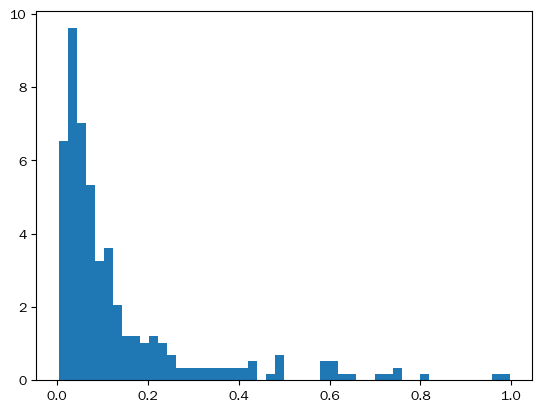

In [27]:
res: list[float] = []
for key, value in m.connectors[BinancePerp].kline_service.containers.items():
    if len(value.klines_1d) > 60:
        _, p, _, _ = value.klines_1d.ordered()
        max_id = np.argmax(p)
        recent_30 = p[-35:-5]  # Избегаем последние 5 дней для надежности
        std_recent_30 = np.std(recent_30)/np.mean(recent_30)
        recent_60_30 = p[-65:-35]  # Избегаем последние 5 дней для надежности
        std_recent_60_30 = np.std(recent_60_30)/np.mean(recent_60_30)
                
        if max_id > 30:
            res.append(np.min(p[max_id:])/p[max_id])

import matplotlib.pyplot as plt

_=plt.hist(res, bins=50, density=True)
np.mean(np.array(res) < 0.1)

In [49]:
i = 0
slow_symbols = set()
active_symbols = set()
for key, value in m.connectors[BinancePerp].kline_service.containers.items():
    if len(value.klines_1d) > 60:
        _, p, _, _ = value.klines_1d.ordered()
        max_id = np.argmax(p)
        recent_30 = p[-35:-5]  # Избегаем последние 5 дней для надежности
        std_recent_30 = np.std(recent_30)/np.mean(recent_30)
        recent_60_30 = p[-65:-35]  # Избегаем последние 5 дней для надежности
        std_recent_60_30 = np.std(recent_60_30)/np.mean(recent_60_30)
                
        if p[-1]/p[-2]-1 > 0.10:
            active_symbols.add(key)    
        if max_id > 2 and p[max_id]/np.min(p[:max_id]) > 2 and np.min(p[max_id:]/p[max_id]) < 0.10 and std_recent_30 < std_recent_60_30:
            i += 1
            slow_symbols.add(key)
            #  print(key, p[max_id]/np.min(p[:max_id]), np.min(p[max_id:]/p[max_id]))
for s in sorted(slow_symbols):
    print(s)

ACHUSDT
AIOTUSDT
ARIAUSDT
ARUSDT
BANANAS31USDT
BASUSDT
BRETTUSDT
BROCCOLIF3BUSDT
BULLAUSDT
FHEUSDT
INJUSDT
JASMYUSDT
JTOUSDT
JUPUSDT
LIGHTUSDT
LYNUSDT
NOTUSDT
ORDIUSDT
PUMPBTCUSDT
RAVEUSDT
RIFUSDT
RUNEUSDT
SAHARAUSDT
SOONUSDT
TAKEUSDT
TRADOORUSDT
TUTUSDT
USELESSUSDT
XPLUSDT


In [53]:
i = 0
active_symbols = set()
for key, value in m.connectors[BinancePerp].kline_service.containers.items():
    if len(value.klines_1d) > 60:
        _, p, _, _ = value.klines_1d.ordered()

        if p[-2]/p[-3]-1 > 0.20:
            print(key, p[-1], p[-2], p[-3], round(p[-1]/p[-2]-1,2), round(p[-2]/p[-3]-1,2))   


USUSDT 0.015793 0.015131 0.012561 0.04 0.2
MAGMAUSDT 0.47596 0.50081 0.37848 -0.05 0.32
GUAUSDT 1.0979 1.0793 0.8959 0.02 0.2
ESPORTSUSDT 0.19803 0.18613 0.06909 0.06 1.69
TAGUSDT 0.0011099 0.001247 0.001028 -0.11 0.21
TACUSDT 0.023658 0.024151 0.015992 -0.02 0.51
MITOUSDT 0.02665 0.02888 0.02144 -0.08 0.35
ZEREBROUSDT 0.0332 0.029477 0.022674 0.13 0.3
CLOUSDT 0.18871 0.1773 0.14269 0.06 0.24
FOLKSUSDT 2.725 2.412 1.945 0.13 0.24
SYNUSDT 0.09167 0.08346 0.05168 0.1 0.61
AGTUSDT 0.027183 0.028069 0.013261 -0.03 1.12
XPLUSDT 0.11105 0.11262 0.09133 -0.01 0.23


In [34]:
symbols: list[str] = []
for key, value in m.connectors[BinancePerp].kline_service.containers.items():
    if len(value.klines_1d) > 60:  # Нужно больше данных
        _, p, _, _ = value.klines_1d.ordered()
        
        # Разбиваем на периоды
        price_now = p[-1]  # Текущая цена
        price_60d_ago = p[-60]
        
        # 1. Был ли дамп? (цена ниже чем 30-60 дней назад)
        max_price_360d = np.max(p[-360:])
        min_price_30d = np.min(p[-30:])
        
        # Памп и дамп: цена упала на 30%+ от максимума
        drawdown = (max_price_360d - price_now) / max_price_360d
        
        # 2. Низкая волатильность в последние 15-20 дней (боковик)
        recent_30 = p[-35:-5]  # Избегаем последние 5 дней для надежности
        std_recent_30 = np.std(recent_30)/np.mean(recent_30)
        recent_60_30 = p[-65:-35]  # Избегаем последние 5 дней для надежности
        std_recent_60_30 = np.std(recent_60_30)/np.mean(recent_60_30)

        # 3. Боковик "внизу" - цена намного ниже исторического максимума
        is_low = price_now < 0.7 * max_price_360d  # На 30%+ ниже ATH за 90 дней
        
        # Условия поиска
        if (drawdown > 0.3 and
            std_recent_30 < std_recent_60_30 and
            is_low):
            
            symbols.append(key)

In [4]:
symbol = "LABUSDT"
for tf in ("1m", "1h", "1d"):
    await asyncio.to_thread(visual.plot_price_and_cumulative_delta_notional, symbol, m.connectors[BinancePerp], tf, "2020-07-03 06:00", "2027-06-07 06:00")

BinancePerp LABUSDT: Данных нет
BinancePerp LABUSDT: Данных нет
BinancePerp LABUSDT: Данных нет


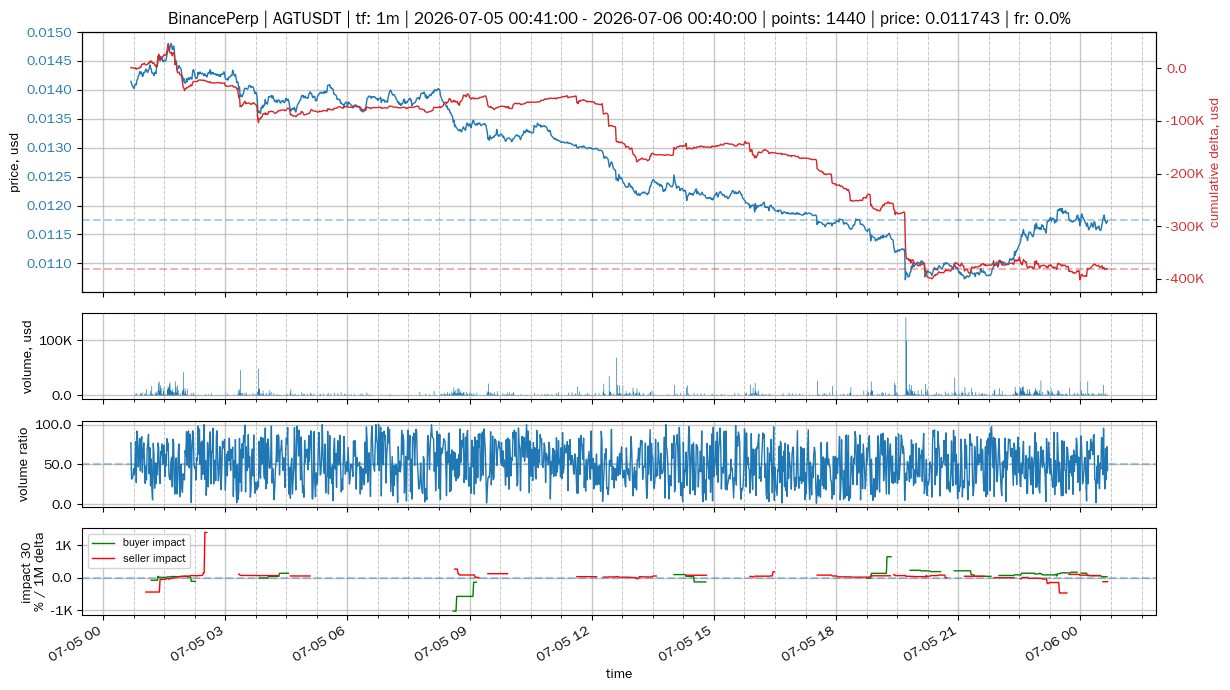

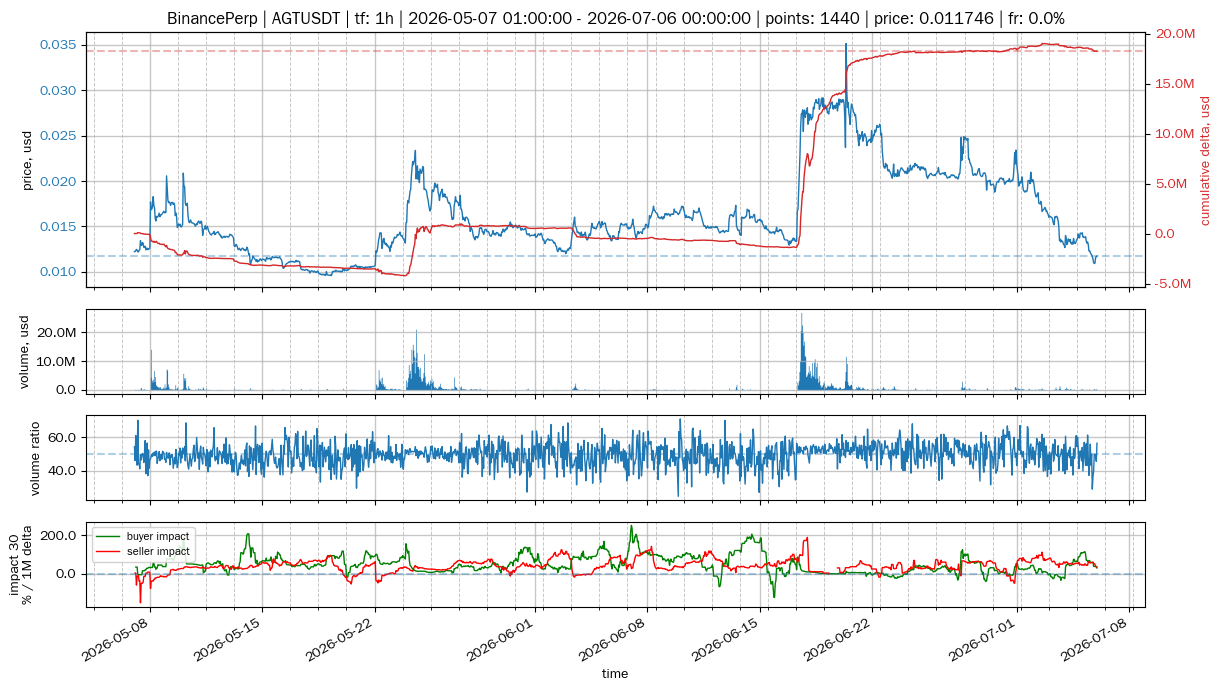

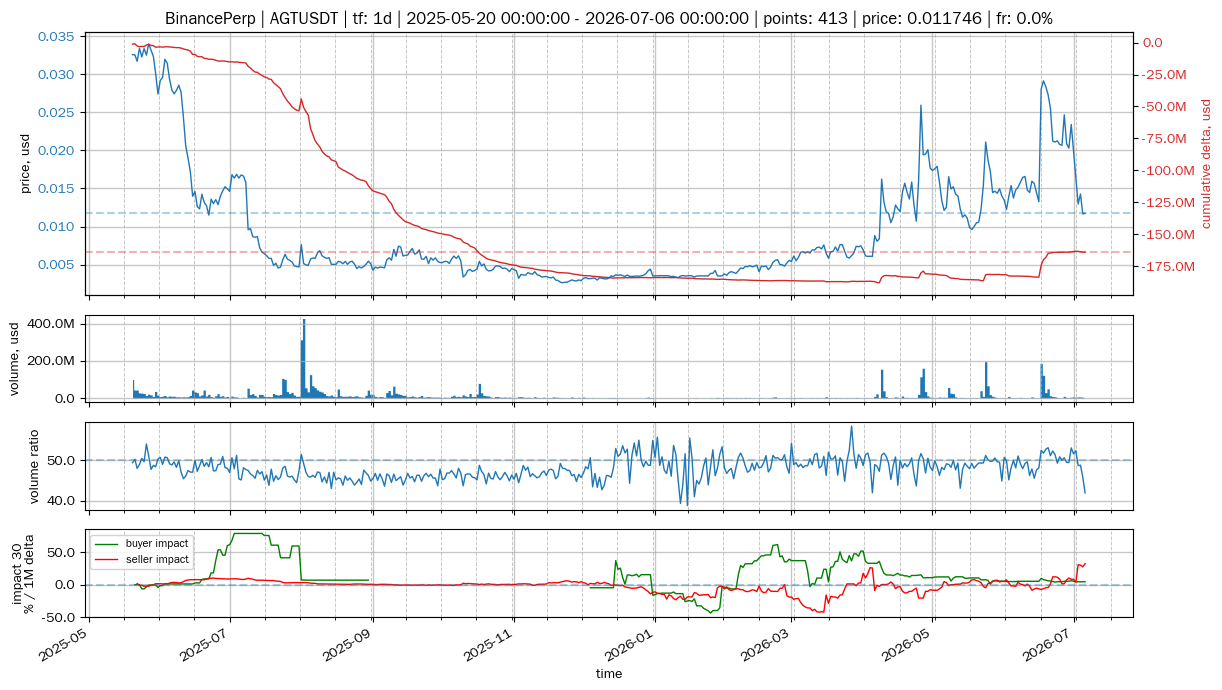

In [4]:
symbol = "AGTUSDT"
for tf in ("1m", "1h", "1d"):
    await asyncio.to_thread(visual.plot_price_and_cumulative_delta_notional, symbol, m.connectors[BinancePerp], tf, "2020-06-21 18:00", "2027-05-26 00:00")

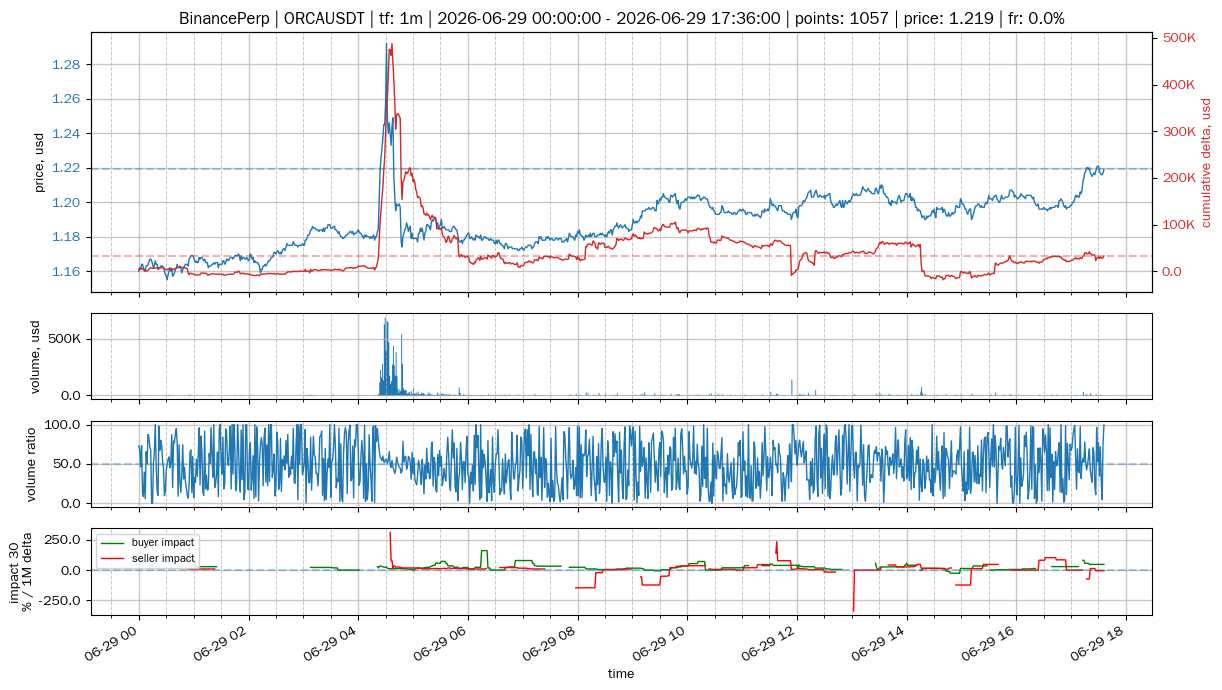

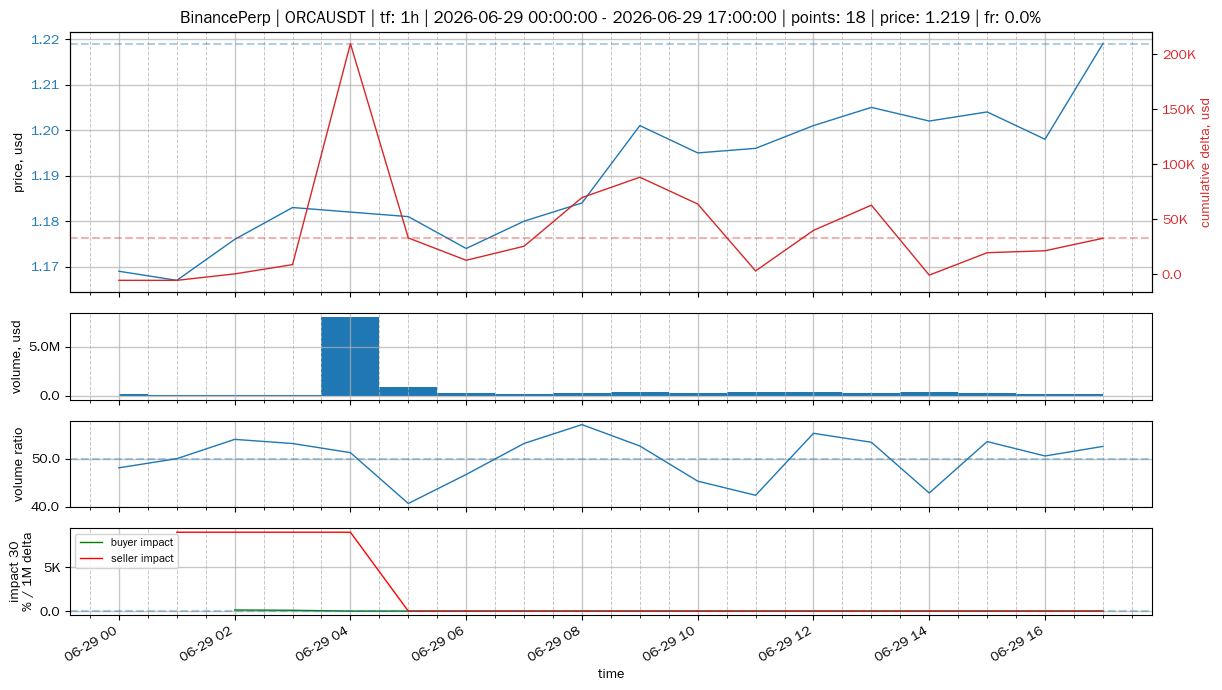

BinancePerp ORCAUSDT: Данных нет


In [16]:
symbol = "ORCAUSDT"
for tf in ("1m", "1h", "1d"):
    await asyncio.to_thread(visual.plot_price_and_cumulative_delta_notional, symbol, m.connectors[BinancePerp], tf, "2026-06-29 00:00", None)

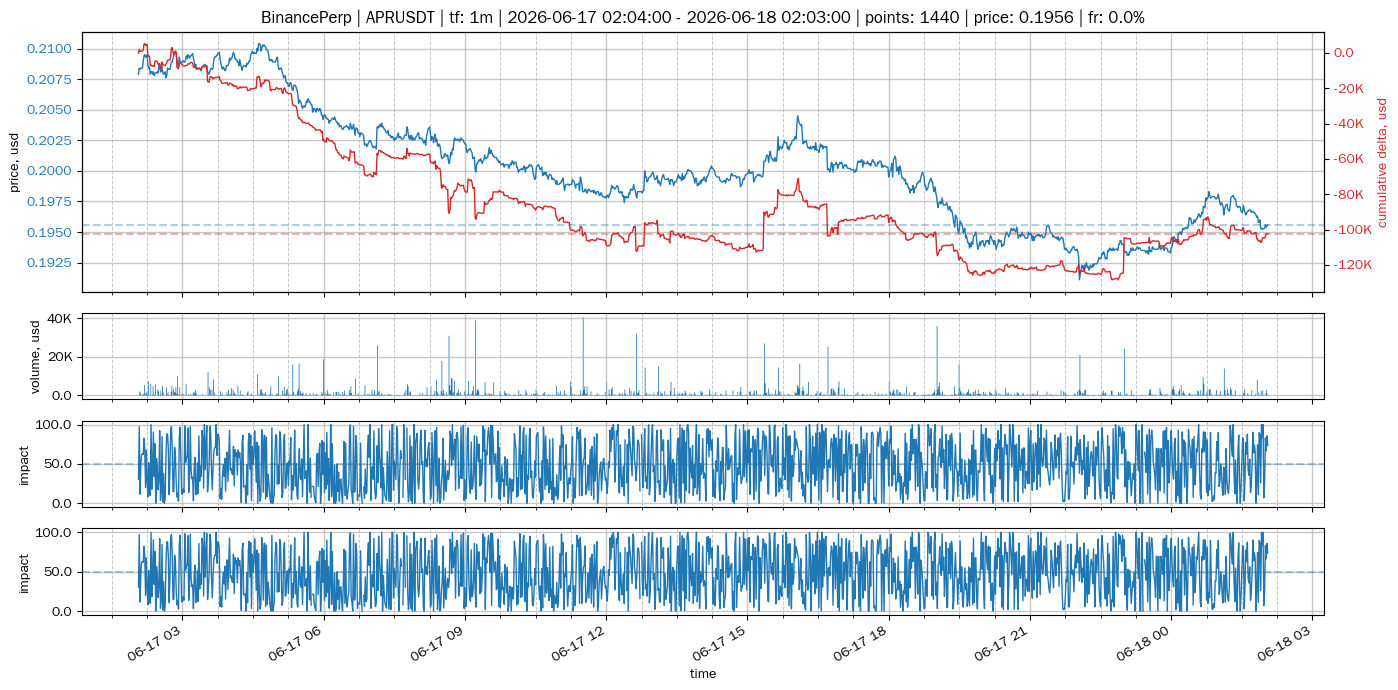

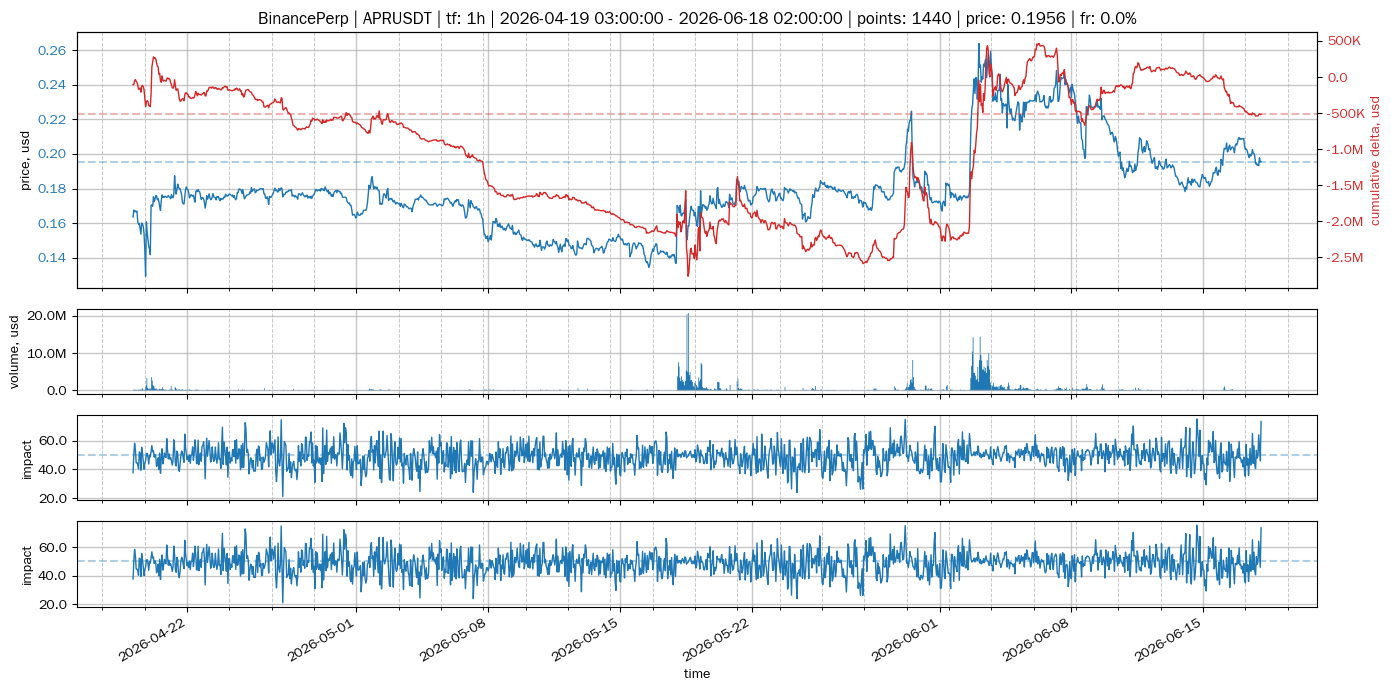

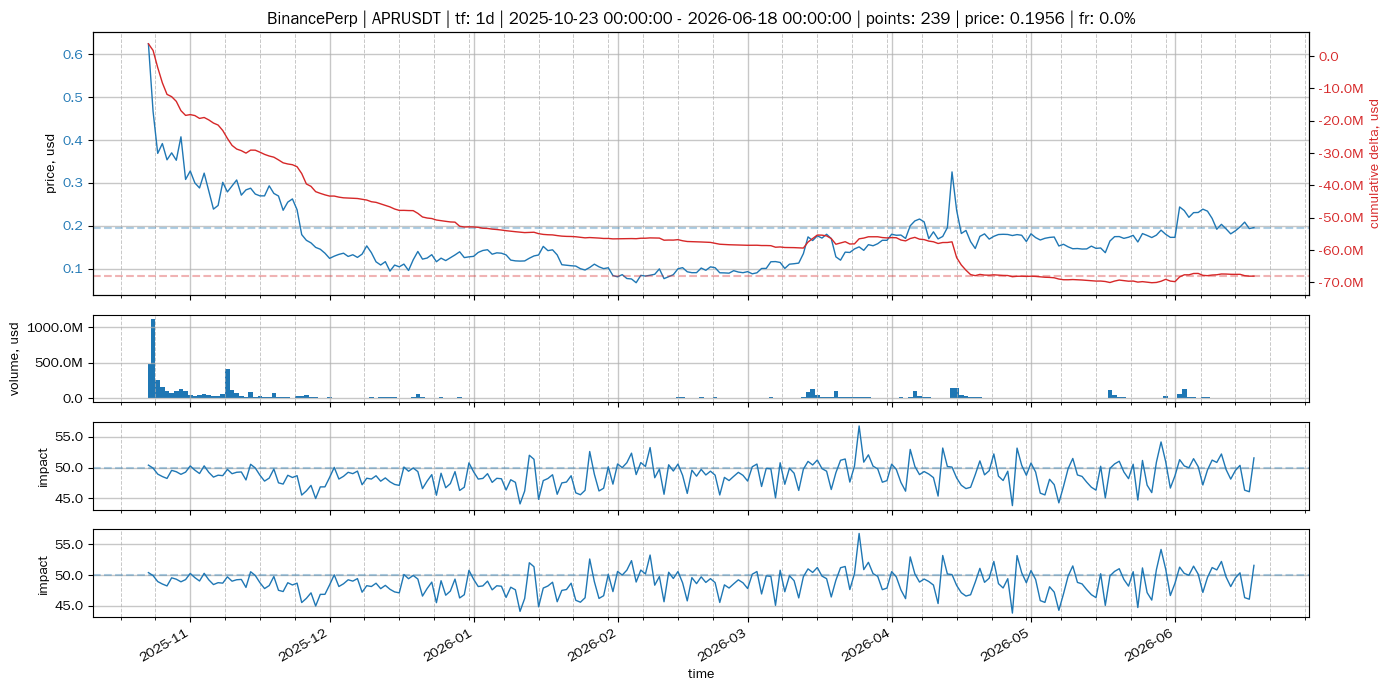

In [6]:
symbol = "APRUSDT"
await asyncio.to_thread(visual.plot_price_and_cumulative_delta_notional, symbol, m.connectors[BinancePerp], "1m")
await asyncio.to_thread(visual.plot_price_and_cumulative_delta_notional, symbol, m.connectors[BinancePerp], "1h")
await asyncio.to_thread(visual.plot_price_and_cumulative_delta_notional, symbol, m.connectors[BinancePerp], "1d")

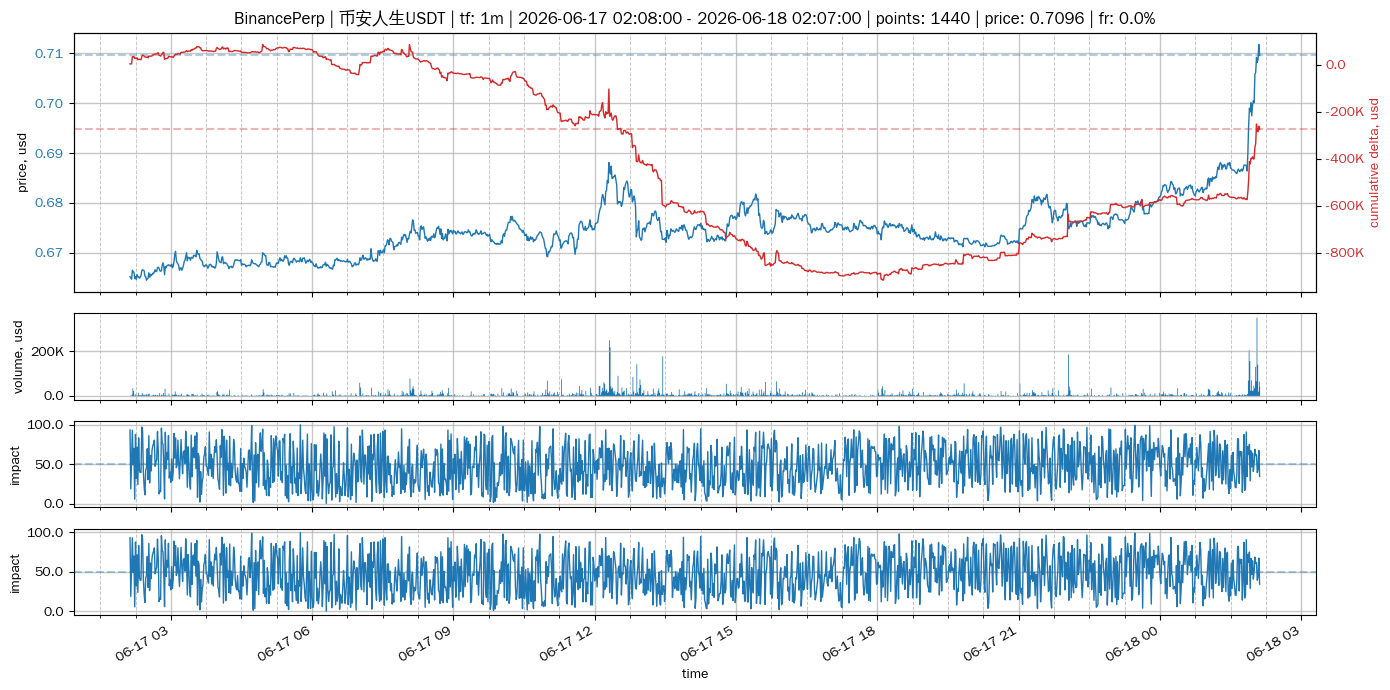

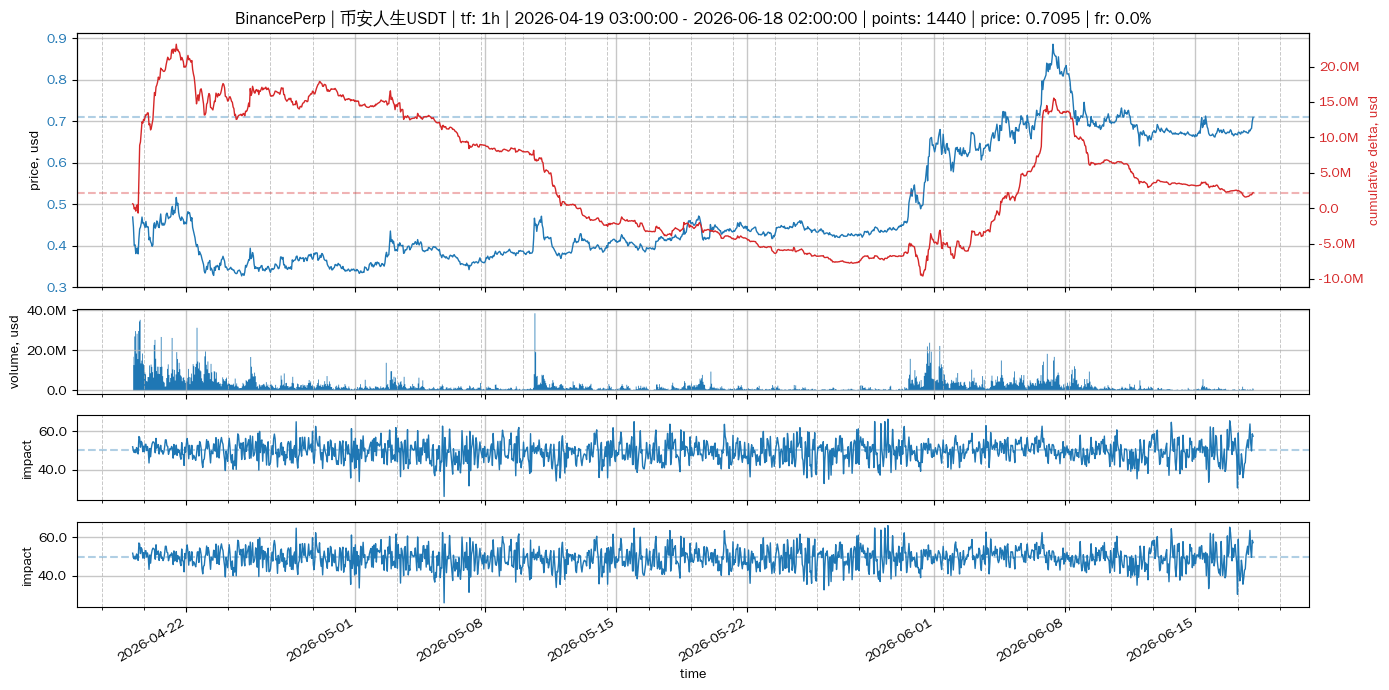

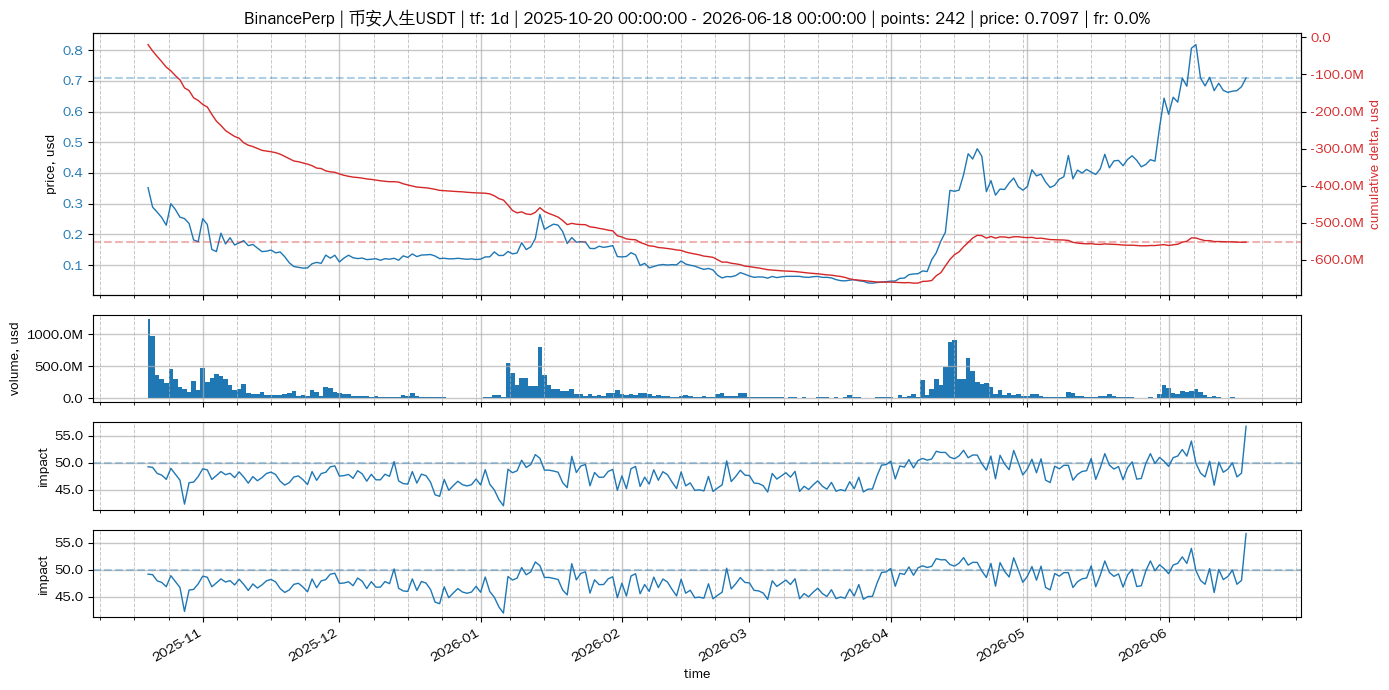

In [7]:
symbol = "币安人生USDT"
await asyncio.to_thread(visual.plot_price_and_cumulative_delta_notional, symbol, m.connectors[BinancePerp], "1m")
await asyncio.to_thread(visual.plot_price_and_cumulative_delta_notional, symbol, m.connectors[BinancePerp], "1h")
await asyncio.to_thread(visual.plot_price_and_cumulative_delta_notional, symbol, m.connectors[BinancePerp], "1d")

In [ ]:
import numpy as np
symbol = "币安人生USDT"
public_trades = m.connectors[BinancePerp].trade_service[symbol].public_trades_1m
idx = public_trades.idx
prices = public_trades.prices
size = len(public_trades)
p = np.concatenate([prices[idx+1:size], prices[:idx]])

tp = round((np.min(p) + np.max(p))/2, 8)
sl = round(np.max(np.diff(p)) * 2 + np.max(p), 8)
price = prices[idx]
rr = round((price-tp)/(sl-price), 2)

print(price, np.max(p), tp, sl, rr)

0.44856 0.51226 0.43548 0.5706 0.11


In [ ]:
import numpy as np
tss = m.connectors[BinancePerp].trade_service["RAVEUSDT"].public_trades_1m.timestamps
ts = np.min(tss)
print(np.datetime64(int(ts), "ms"), len(tss))


2026-04-12T17:47:00.000 1440


In [ ]:
import numpy as np
tss = m.connectors[BinancePerp].trade_service["RAVEUSDT"].public_side_trades.timestamps
ts = np.min(tss)
print(np.datetime64(int(ts), "ms"), len(tss))

2026-04-13T17:36:46.046 10000


In [ ]:
symbol = "GWEIUSDT"
await asyncio.to_thread(visual.plot_price_and_cumulative_delta_notional, symbol, m.connectors[BinancePerp], "1m")

In [ ]:
import importlib

from config import bi_api_key as api_key, bi_secret_key as secret_key
import bi_exchange as bi
import aiohttp

importlib.reload(bi)

symbol = "AIAUSDT"
optimal_f = 0.02


async with aiohttp.ClientSession() as session:
    response, _ = await bi.http_request(
        method=bi.HTTPMethod.GET, session=session, url=bi.url_future_base + "v3/account", params={}, api_key=api_key, secret_key=secret_key
    )
    equity = float(response["totalWalletBalance"])

print(equity)

perp = perps[symbol]
brackets = perp.features["brackets"]
feature = perp.features["1s"]
prices = np.abs(feature["last_price"].get_data())
current_price = round(float(prices[-1]) // perp.price_step * perp.price_step, perp.price_precision)
max_price = round(float(np.max(prices)) // perp.price_step * perp.price_step, perp.price_precision)
# max_price = round(float(20.3)//perp.price_step*perp.price_step, perp.price_precision)
sl_value = round(equity * optimal_f)
sl_liq_target = round(sl_value * 1.25)
qty = round(sl_value / (max_price - current_price) // perp.qty_step * perp.qty_step, perp.qty_precision)
position_amount = qty * current_price
liquidationFee = perp.features["liquidationFee"]

max_initial_leverage: int = 1
for row in brackets:
    if row["notionalFloor"] < position_amount < row["notionalCap"]:
        max_initial_leverage = row["initialLeverage"]
        mmr = row["maintMarginRatio"]
        mma = row["cum"]


leverage = 1 / ((sl_liq_target + mma) / position_amount + mmr + liquidationFee)

print(f"price: {current_price}, hi: {max_price}, sl: {sl_value}, sl_liq： {sl_liq_target}, qty: {qty}, pos_value: {position_amount}, lev: {leverage}, max_lev: {max_initial_leverage}")

params = {
    "symbol": symbol,
    "side": "SELL",
    "type": "limit",
    "timeInForce": "GTX",
    "reduceOnly": "false",
    "price": str(current_price),
    "quantity": str(qty),
    "stopPrice": str(max_price),
    # "newClientOrderId": order.custom_id,
}

In [ ]:
plot_price_and_cumulative_delta_notional(
    symbol="PLAYUSDT",
    connector=m.connectors[BinancePerp],
    feature="1m",
    from_date_utc="2026-04-08T01:50:00",
    resistance_bucket="15min",
    resistance_bps_floor=1.0,
    resistance_min_blocks=3,
    resistance_ewm_span=6,
    volume_is_notional=False,
)

In [ ]:
perp_symbols = set(instrument.unified_symbol for instrument in m.connectors[BinancePerp].instrument_manager.values())
spot_symbols = set(instrument.unified_symbol for instrument in m.connectors[BinanceSpot].instrument_manager.values())
unified_symbols = perp_symbols & spot_symbols
len(perp_symbols), len(spot_symbols), len(unified_symbols)

(542, 439, 371)

In [ ]:
import numpy as np
symbol = "币安人生USDT"
public_trades = m.connectors[BinancePerp].trade_service[symbol].public_trades_1m
idx = public_trades.idx
prices = public_trades.prices
size = len(public_trades)
p = np.concatenate([prices[idx+1:size], prices[:idx]])

tp = round((np.min(p) + np.max(p))/2, 8)
sl = round(np.max(np.diff(p)) * 2 + np.max(p), 8)
price = prices[idx]
rr = round((price-tp)/(sl-price), 2)

print(price, np.max(p), tp, sl, rr)

0.38813 0.52851 0.44869 0.58107 -0.31


In [ ]:
from datetime import datetime, timezone

s = "20260419 12:00"

a = int(datetime.fromisoformat(s).timestamp() * 1000)
b = int(datetime.fromisoformat(s).replace(tzinfo=timezone.utc).timestamp() * 1000)

print(a, b, a - b)

1776564000000 1776600000000 -36000000


In [ ]:
from datetime import datetime

now_local = datetime.now().astimezone()

print("local datetime:", now_local)
print("tzinfo:", now_local.tzinfo)
print("utc offset:", now_local.utcoffset())

local datetime: 2026-04-19 18:31:34.987599+10:00
tzinfo: +10
utc offset: 10:00:00
